In [34]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import pickle
import scipy.spatial as ss

import seaborn as sns
import shap
import warnings

from functools import reduce
from PIL import Image
#from sklearn.linear_model import LogisticRegression
#from sklearn.svm import SVC
#from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale, LabelEncoder
from xgboost import XGBClassifier


In [2]:
warnings.filterwarnings("ignore")

In [3]:
def get_path(*args):
  ## Function to get the path
  path = os.path.join(*args)
  return path

def df_report(df):
  shape = df.shape
  info = df.info()
  df.describe()
  return shape, info, df.describe()

In [4]:
BASE_PATH = os.path.join(os.getcwd(), '../')
DATA_PATH = get_path(BASE_PATH, "data")
ORIGINAL_DATA_PATH = get_path(DATA_PATH, "original")
GAMES_PATH = get_path(ORIGINAL_DATA_PATH, "games.csv")
PLAYERS_PATH = get_path(ORIGINAL_DATA_PATH, "players.csv")
PLAYS_PATH = get_path(ORIGINAL_DATA_PATH, "plays.csv")
PLAYER_PLAY_PATH = get_path(ORIGINAL_DATA_PATH, "player_play.csv")
TRACKING_PATH = get_path(ORIGINAL_DATA_PATH, "tracking")

In [5]:
games_df = pd.read_csv(GAMES_PATH)
players_df = pd.read_csv(PLAYERS_PATH)
play_df = pd.read_csv(PLAYS_PATH)
#players_play_df = pd.read_csv(PLAYER_PLAY_PATH)

tracking_df = pd.concat([
    pd.read_csv(get_path(TRACKING_PATH, f))for f in os.listdir(TRACKING_PATH)[-1:]
])

In [6]:
def plot_field(subplots=2, figsize=(15,10)):
  '''Function to plot the football field. '''
  stadium_limit_dimension_y =  (0, 53.3333333)
  stadium_limit_dimension_x = (0, 120)
  color__green = "#586d3d"
  color__white = "#DADADA"
  color__brown = "#663831"
  color__yellow = "#cbb67c"
  text_position = 5
  portery_yards = 6.166667
  numbers = {20:'1 0', 30:'2 0', 40:'3 0', 50:'4 0', 60:'5 0', 70:'4 0', 80:'3 0', 90:'2 0', 100:'1 0'}

  fig, ax = plt.subplots(subplots, figsize=figsize)
  ax[0].set_xlim(stadium_limit_dimension_x)
  ax[0].set_ylim(stadium_limit_dimension_y)
  ax[0].vlines(
      [i for i in range(0, max(stadium_limit_dimension_x), 10)],
      min(stadium_limit_dimension_y),
      max(stadium_limit_dimension_y),
      color=color__white,
      alpha=0.5
  )

  ax[0].vlines(
      [i for i in range(10, max(stadium_limit_dimension_x)-10, 5)],
      min(stadium_limit_dimension_y),
      max(stadium_limit_dimension_y),
      color=color__white,
      alpha=0.3
  )

  vlines2 = [i for i in range(10, max(stadium_limit_dimension_x)-10+1, 1)]
  vlines2_size=1
  ax[0].vlines(
      vlines2,
      min(stadium_limit_dimension_y),
      min(stadium_limit_dimension_y) + vlines2_size,
      color=color__white,
      alpha=0.3
  )
  ax[0].vlines(
      vlines2,
      max(stadium_limit_dimension_y),
      max(stadium_limit_dimension_y) - vlines2_size,
      color=color__white,
      alpha=0.5
  )

  vlines3_size = 0.5
  medium_vlines_pos = (min(stadium_limit_dimension_y) + max(stadium_limit_dimension_y))/2 + portery_yards/2
  medium_vlines_neg = (min(stadium_limit_dimension_y) + max(stadium_limit_dimension_y))/2 - portery_yards/2
  ax[0].vlines(
      vlines2,
      medium_vlines_pos + vlines3_size,
      medium_vlines_pos - vlines3_size,
      color=color__white,
      alpha=0.3
  )
  ax[0].vlines(
      vlines2,
      medium_vlines_neg + vlines3_size,
      medium_vlines_neg - vlines3_size,
      color=color__white,
      alpha=0.3
  )
  for p, n in numbers.items():
    ax[0].text(p, min(stadium_limit_dimension_y) + text_position, n, horizontalalignment='center', verticalalignment='center', color=color__white, rotation=0)
    ax[0].text(p, max(stadium_limit_dimension_y) - text_position, n, horizontalalignment='center', verticalalignment='center', color=color__white, rotation=180)

  triangle_pos = [(i + (i-5))/2 for i in range(20, max(stadium_limit_dimension_x)//2-10+1, 10)]
  ax[0].scatter(triangle_pos, [min(stadium_limit_dimension_y) + text_position]*len(triangle_pos), marker='<', s=10, color=color__white)
  ax[0].scatter(triangle_pos, [max(stadium_limit_dimension_y) - text_position]*len(triangle_pos), marker='<', s=10, color=color__white)

  triangle_pos2 = [(i + (i+5))/2 for i in range(70, max(stadium_limit_dimension_x)-10, 10)]
  ax[0].scatter(triangle_pos2, [min(stadium_limit_dimension_y) + text_position]*len(triangle_pos2), marker='>', s=10, color=color__white)
  ax[0].scatter(triangle_pos2, [max(stadium_limit_dimension_y) - text_position]*len(triangle_pos2), marker='>', s=10, color=color__white)
  ax[0].set_facecolor(color__green)
  ax[0].set_xticks([])
  ax[0].set_yticks([])
  return fig, ax

def draw_graph2(G, ax=None):
    '''Function to plot teams as graphs, with ball.'''
    colors = {-1: "tab:blue", 1:'tab:orange', 0:'brown'}
    node_colors = []
    pos_dict = {}
    for node, attr in G.nodes(data=True):
        team_def = attr["team_deffinition"]
        node_colors.append(colors[team_def])
        pos_dict[node] = np.array([attr["pos_x"],attr["pos_y"]])
    edges = G.edges(data=True)
    weights = [v[-1]['weight'] for v in edges]
    pos = pos_dict
    ec = nx.draw_networkx_edges(G, pos, width=weights, alpha=0.5, ax=ax)
    nc = nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=50, alpha=0.5, ax=ax)

In [7]:
def influence_function(analysis_unit):
    mean_x = analysis_unit.x + 0.5*analysis_unit.s* np.cos(np.deg2rad(analysis_unit.dir))
    mean_y = analysis_unit.y + 0.5*analysis_unit.s* np.sin(np.deg2rad(analysis_unit.dir))
    
    max_speed = 20 #Max speed proposed in paper over the tracking data
    influence_radius = 3  # Influence in yards of the player. (max dis)
    s_rat = (analysis_unit.s/max_speed)**2
    
    sx = (influence_radius + influence_radius * s_rat) / 2
    sy = (influence_radius - influence_radius * s_rat) / 2
    
    diag_cov_comp1 = sx**2*np.cos(np.deg2rad(analysis_unit.dir))**2
    diag_cov_comp2 = sy**2*np.cos(np.deg2rad(analysis_unit.dir))**2
    
    cov_matrix_det = np.cos(np.deg2rad(analysis_unit.dir))**4 * sx ** 2 * sy ** 2
    
    def matrix_multiplication_result(pos_x, pos_y):
        x_comp = sx ** 2 * np.cos(np.deg2rad(analysis_unit.dir)) ** 2 * (pos_x - mean_x) ** 2
        y_comp = sy ** 2 * np.cos(np.deg2rad(analysis_unit.dir)) ** 2 * (pos_y - mean_y) ** 2
        tot_comp = x_comp + y_comp
        return tot_comp
    influence_sign = analysis_unit.team_deffinition
    
    func = lambda pos_x, pos_y: influence_sign * (1 / np.sqrt(2*np.pi*cov_matrix_det) * np.exp((-1/2)* matrix_multiplication_result(pos_x, pos_y)))
    return func

def influence_function_actual_pos(analysis_unit):
    pos_x = analysis_unit.x
    pos_y = analysis_unit.y
    
    mean_x = analysis_unit.x + 0.5*analysis_unit.s* np.cos(np.deg2rad(analysis_unit.dir))
    mean_y = analysis_unit.y + 0.5*analysis_unit.s* np.sin(np.deg2rad(analysis_unit.dir))
    
    max_speed = 20 #Max speed proposed in paper over the tracking data
    influence_radius = 3  # Influence in yards of the player. (max dis)
    s_rat = (analysis_unit.s/max_speed)**2
    
    sx = (influence_radius + influence_radius * s_rat) / 2
    sy = (influence_radius - influence_radius * s_rat) / 2
    
    diag_cov_comp1 = sx**2*np.cos(np.deg2rad(analysis_unit.dir))**2
    diag_cov_comp2 = sy**2*np.cos(np.deg2rad(analysis_unit.dir))**2
    
    cov_matrix_det = np.cos(np.deg2rad(analysis_unit.dir))**4 * sx ** 2 * sy ** 2
    
    x_comp = sx ** 2 * np.cos(np.deg2rad(analysis_unit.dir)) ** 2 * (pos_x - mean_x) ** 2
    y_comp = sy ** 2 * np.cos(np.deg2rad(analysis_unit.dir)) ** 2 * (pos_y - mean_y) ** 2
    matrix_multiplication_result = x_comp + y_comp
    influence_sign = analysis_unit.team_deffinition
    interaction =  influence_sign * (1 / np.sqrt(2*np.pi*cov_matrix_det) * np.exp((-1/2)* matrix_multiplication_result))
    return interaction

In [8]:
# We can create a graph
def angle_matrix(x, y, p=2, threshold=1000000):
  x = np.asarray(x)
  y = np.asarray(y)
  x = x[:,np.newaxis,:]
  y = y[np.newaxis,:,:]
  x_y = y-x
  arctan_vals = np.arctan2(x_y[:,:,1], x_y[:,:,0])*180/np.pi
  arctan_vals[arctan_vals < 0] = arctan_vals[arctan_vals < 0] + 360
  return arctan_vals

def get_analysis_unit_without_ball(analysis_unit):
  analysis_unit_without_ball = analysis_unit[analysis_unit.club!='football']
  return analysis_unit_without_ball

def get_look_matrix(analysis_unit, not_ball=True):
  analysis_unit = analysis_unit.copy()
  if not_ball:
    analysis_unit = get_analysis_unit_without_ball(analysis_unit)
  # Get the analysis unit without the ball.

  # Get the angle matrix, depending in positions.
  angles_according_to_position = angle_matrix(
      analysis_unit[['x', 'y']],
      analysis_unit[['x', 'y']]
      )
  # Compare if positions are aligned to orientation or direction.
  angles_according_to_position_o = angles_according_to_position - np.asarray(analysis_unit.o)
  angles_according_to_position_dir = angles_according_to_position - np.asarray(analysis_unit.dir)
  # Normalize the direction with cosine
  # (if aligned then 1, if not then 0, and any values between that, also negative alignment is possible).
  look_o = np.cos(np.deg2rad(angles_according_to_position_o)) # Relevance depending in direction
  look_dir = np.cos(np.deg2rad(angles_according_to_position_dir))
  # Sum the contribution of both alingments, at 50%50.
  look = (look_o + look_dir)/2
  look = np.nan_to_num(look, nan=0)
  look = np.matrix.transpose(look)
  return look

def get_inverse_distance_matrix_weighted_by_look(analysis_unit, not_ball=False):
  inverse_distance_matrix = get_inverse_distance_matrix(analysis_unit, not_ball=not_ball, power=1)
  look = get_look_matrix(analysis_unit, not_ball=not_ball)
  #inverse_distance_matrix_weighted = inverse_distance_matrix + 10*look
  inverse_distance_matrix_weighted = inverse_distance_matrix*look
  return inverse_distance_matrix_weighted

def get_team_positions(analysis_unit, not_ball=True):
  analysis_unit = analysis_unit.copy()
  if not_ball:
    analysis_unit = get_analysis_unit_without_ball(analysis_unit)
  pos = analysis_unit[['x', 'y']].reset_index(drop=True)
  pos['xy'] = pos.apply(lambda x: np.array([x.x, x.y]), axis=1)
  pos = pos['xy'].to_dict()
  return pos

def get_inverse_distance_matrix(analysis_unit, power=1, not_ball=True):
  analysis_unit = analysis_unit.copy()
  if not_ball:
    analysis_unit = get_analysis_unit_without_ball(analysis_unit)
  # Get distance matrix
  unit_distance_matrix = ss.distance_matrix(
      analysis_unit[['x', 'y']],
      analysis_unit[['x', 'y']])
  # Divide 1 over the values by a power
  inverse_distance_matrix = 1/unit_distance_matrix**(power)
  # Replace infinite with 0
  inverse_distance_matrix[inverse_distance_matrix==np.inf] = 0
  inverse_distance_matrix = np.nan_to_num(inverse_distance_matrix, nan=0)
  return inverse_distance_matrix

def get_team_graph(analysis_unit, not_ball=False):
  matrix = get_inverse_distance_matrix_weighted_by_look(analysis_unit, not_ball=not_ball)
  G = nx.from_numpy_array(matrix, create_using=nx.MultiDiGraph()) # Must be multidigraph
  return G

def get_team_graph_no_negative(analysis_unit, not_ball=False):
  matrix = get_inverse_distance_matrix_weighted_by_look(analysis_unit, not_ball=not_ball)
  matrix[matrix<0] = 0
  G = nx.from_numpy_array(matrix, create_using=nx.MultiDiGraph()) # Must be multidigraph
  return G

def get_graph_with_nodes_attrs(analysis_unit, not_ball=False, no_negatives=False):
  if no_negatives:
    g = get_team_graph_no_negative(analysis_unit, not_ball=not_ball)
  else:
    g = get_team_graph(analysis_unit, not_ball=False)

  nx.set_node_attributes(g, analysis_unit.reset_index(drop=True).action.to_dict(), 'action')
  nx.set_node_attributes(g, analysis_unit.reset_index(drop=True).ke.to_dict(), 'ke')
  nx.set_node_attributes(g, analysis_unit.reset_index(drop=True).p.to_dict(), 'p')
  nx.set_node_attributes(g, analysis_unit.reset_index(drop=True).f.to_dict(), 'f')
  nx.set_node_attributes(g, analysis_unit.reset_index(drop=True).work.to_dict(), 'work')
  nx.set_node_attributes(g, analysis_unit.reset_index(drop=True).team_deffinition.fillna(0).to_dict(), 'team_deffinition')
  nx.set_node_attributes(g, analysis_unit.reset_index(drop=True).x.to_dict(), 'pos_x')
  nx.set_node_attributes(g, analysis_unit.reset_index(drop=True).y.to_dict(), 'pos_y')
  nx.set_node_attributes(g, analysis_unit.reset_index(drop=True).y.to_dict(), 'encoded_position')

  # Graph computables
  #nx.set_node_attributes(g, nx.centrality.trophic_levels(g, weight='weight'), 'trophic_level')
  #nx.set_node_attributes(g, dict(g.degree(weight='weight')), 'degree')
  #nx.set_node_attributes(g, nx.betweenness_centrality(g, weight='weight'), 'betweenness_centrality')


  #additional_network_features = pd.DataFrame()
  #additional_network_features['betweenness_centrality'] = nx.centrality.betweenness_centrality(g, weight='weight')
  #additional_network_features['percolation_centrality_action'] = nx.centrality.percolation_centrality(g, weight='weight', attribute='action')
  #additional_network_features['percolation_centrality_ke'] = nx.centrality.percolation_centrality(g, weight='weight', attribute='ke')
  #additional_network_features['percolation_centrality_p'] = nx.centrality.percolation_centrality(g, weight='weight', attribute='p')
  #additional_network_features['percolation_centrality_f'] = nx.centrality.percolation_centrality(g, weight='weight', attribute='f')
  #additional_network_features['percolation_centrality_work'] = nx.centrality.percolation_centrality(g, weight='weight', attribute='work')

  #additional_network_features['betweeness_residual_action_percolation'] = additional_network_features.betweenness_centrality - additional_network_features.percolation_centrality_action
  #additional_network_features['betweeness_residual_ke_percolation'] = additional_network_features.betweenness_centrality - additional_network_features.percolation_centrality_ke
  #additional_network_features['betweeness_residual_p_percolation'] = additional_network_features.betweenness_centrality - additional_network_features.percolation_centrality_p
  #additional_network_features['betweeness_residual_f_percolation'] = additional_network_features.betweenness_centrality - additional_network_features.percolation_centrality_f
  #additional_network_features['betweeness_residual_work_percolation'] = additional_network_features.betweenness_centrality - additional_network_features.percolation_centrality_work

  #additional_network_features.drop(
  #    ['percolation_centrality_action',
  #    'percolation_centrality_ke',
  #    'percolation_centrality_p',
  #    'percolation_centrality_f',
  #    'percolation_centrality_work'], axis=1, inplace=True)

  #for col in additional_network_features.columns:
  #  nx.set_node_attributes(g, additional_network_features[col].to_dict(), col)
  return g

def get_laplacian_matrix(g, weight='weight'):
    # Laplacian = adjacency - degree
    adj_matrix = nx.adjacency_matrix(g, weight=weight).toarray()
    degree_matrix = np.diag(np.array((g.degree(weight=weight)))[:,1])
    laplacian_matrix = adj_matrix - degree_matrix
    return laplacian_matrix

# Embedding fgsd:
def get_fgsd_embedding(g, replicability_nb=3):
  laplacian_matrix = get_laplacian_matrix(g, weight='weight') 
  inverted_laplacian_matrix = np.linalg.pinv(laplacian_matrix)
  ones = np.ones(laplacian_matrix.shape[0])
  S = np.outer(np.diag(inverted_laplacian_matrix), ones) + np.outer(ones, np.diag(inverted_laplacian_matrix)) - 2 * inverted_laplacian_matrix
  hist, _ = np.histogram(S.flatten(), bins=22*replicability_nb)
  hist = hist/hist.sum()
  return hist

def get_laplacian_embedding(g, replicability_nb=2):
  laplacian_matrix = get_laplacian_matrix(g, weight='weight') # Laplacian = adjacency - degree
  hist, _ = np.histogram(laplacian_matrix.flatten(), bins=22*replicability_nb)
  hist = hist/hist.sum()
  return hist

def get_adjacent_embedding(g, replicability_nb=2):
  laplacian_matrix = nx.adjacency_matrix(g, weight='weight').toarray() # Laplacian = adjacency - degree
  hist, _ = np.histogram(laplacian_matrix.flatten(), bins=22*replicability_nb)
  hist = hist/hist.sum()
  return hist

# Embedding feather
def get_feathergraph_embedding(g):
  adjacency_matrix = nx.adjacency_matrix(g, weight='weight').toarray()
  degree_inverse = np.diag(1/np.array((g.degree(weight='weight')))[:,1])
  normalized_adjacency_matrix = degree_inverse.dot(adjacency_matrix)

  node_features = pd.DataFrame(
      dict(g.nodes(data=True))
  ).T

  scaled_node_features = pd.DataFrame(
      scale(node_features, axis=0),
      index=node_features.index,
      columns=node_features.columns
  )
  #scaled_node_features = node_features

  theta = np.linspace(np.pi//2, 2*np.pi+np.pi//2, 360//24)
  outer_scaled_node_features = np.outer(scaled_node_features, theta).reshape(g.number_of_nodes(), -1)
  outer_scaled_node_features_transformed = np.concatenate([np.cos(outer_scaled_node_features), np.sin(outer_scaled_node_features)], axis=1)
  modified_outer_scaled_node_features_transformed = outer_scaled_node_features_transformed.copy()

  feature_blocks = []
  for _ in range(5):
    modified_outer_scaled_node_features_transformed = normalized_adjacency_matrix.dot(modified_outer_scaled_node_features_transformed)
    feature_blocks.append(modified_outer_scaled_node_features_transformed)

  feature_blocks = np.concatenate(feature_blocks, axis=1)
  feather_feature_blocks =  np.mean(feature_blocks, axis=0)
  return feather_feature_blocks


def get_pca_feather_embeddings(pca, x):
    feather_embeddings_columns = [col for col in x.columns if "embedding" in col]
    feather_embeddings =  x[feather_embeddings_columns].fillna(-1)
    pca_feather_embeddings = pca.transform(feather_embeddings)
    columns = [f'pca_feather_embedding_{i}' for i in range(pca_feather_embeddings.shape[1])]
    df_pca_feather_embeddings = pd.DataFrame(pca_feather_embeddings, index=x.index, columns=columns)
    x.drop(columns=feather_embeddings_columns, inplace=True)
    new_x = pd.merge(x, df_pca_feather_embeddings, left_index=True, right_index=True, how='left')
    return new_x    

In [9]:
with open('../models/models1/lb_player_position.pkl', 'rb') as f:
    lb_player_position = pickle.load(f)

with open('../models/models1/pca.pkl', 'rb') as f:
    pca_model = pickle.load(f)

with open('../models/models1/model.pkl', 'rb') as f:
    model = pickle.load(f)

In [10]:
def get_metrics_distance_between_team_players(df):
  distances = ss.distance_matrix(
      df[df.team_deffinition == -1][['x','y']],
      df[df.team_deffinition == 1][['x', 'y']]
  )
  distance_metrics = {
      'distance_between_teams_min': np.min(distances),
      'distance_between_teams_max': np.max(distances),
      'distance_between_teams_mean': np.mean(distances),
      'distance_between_teams_std': np.std(distances),
  }
  return distance_metrics

def obtaining_game_and_play_ids(gameplay_id):
    game, play, frame= gameplay_id.split('_')
    return game, play

cols = ['gameId', 'playId', 'frameId', 'frameType', 'time', 'playDirection', 'event']

def compute_features(df):
    df = df.copy()
    play_df['game_play'] = play_df.gameId.astype('str') + '_' + play_df.playId.astype('str')
    df['game_play'] = df.gameId.astype('str') + '_' + df.playId.astype('str')
    df['game_play_frame_id'] = df.gameId.astype('str') + '_' + df.playId.astype('str') + '_' + df.frameId.astype('str')

    event_occurence = df.drop_duplicates(['gameId', 'playId','frameId'])[cols]
    event_occurence['game_play_frame_id'] = event_occurence.apply(lambda x: f'{x.gameId}_{x.playId}_{x.frameId}', axis=1)
    
    reduced_play_df = play_df[play_df.game_play.isin(df['game_play'])]

    reduced_play_df['team_deffinition'] = reduced_play_df.apply(lambda x: {x.possessionTeam: 1, x.defensiveTeam: -1}, axis=1)
    reduced_play_df['gameClock_time'] = reduced_play_df.gameClock.str.split(':').apply(lambda x: int(x[0])*60 + int(x[1]))
    reduced_play_df['preSnapScore_difference'] = reduced_play_df['preSnapHomeScore'] - reduced_play_df['preSnapVisitorScore']
    reduced_play_df['receiverAlignment_0'] = reduced_play_df.receiverAlignment.fillna('0x0').str.split('x').apply(lambda x: x[0])
    reduced_play_df['receiverAlignment_1'] = reduced_play_df.receiverAlignment.fillna('0x0').str.split('x').apply(lambda x: x[1])

    reduced_play_columns = [
        'quarter',
        'down',
        'yardsToGo',
        'yardlineNumber',
        'absoluteYardlineNumber',
        'preSnapHomeTeamWinProbability',
        'preSnapVisitorTeamWinProbability',
        'gameClock_time',
        'receiverAlignment_0',
        'receiverAlignment_1',
        'game_play',
        'team_deffinition',
    ]
    reduced_play_df = reduced_play_df[reduced_play_columns]


    new_player_info_df = df.merge(players_df, on='nflId', how='left')[
        ['nflId','x', 'y','club', 's', 'a', 'dir','event', 'weight', 'position', 'dis', 'o', 'game_play_frame_id', 'game_play']
    ]
    new_player_info_df["encoded_position"] = lb_player_position.transform(new_player_info_df.position)
    new_player_info_df.drop(columns=['position'], inplace=True)
    new_player_info_df.loc[new_player_info_df.fillna(0).dir==90, 'dir'] = 91
    new_player_info_df.loc[new_player_info_df.fillna(0).dir==270, 'dir'] = 269
    new_player_info_df = new_player_info_df.merge(reduced_play_df[['game_play', 'team_deffinition']], on='game_play', how='left')

    new_player_info_df['team_deffinition'] = new_player_info_df.apply(
        lambda row: row.team_deffinition.get(row.club), axis=1
    )
    new_player_info_df.loc[new_player_info_df.club=='football', 'weight'] =  1.11

    new_player_info_df['current_position_influence'] = new_player_info_df.apply(influence_function_actual_pos, axis=1)
    new_player_info_df['action'] = new_player_info_df.weight*new_player_info_df.s*new_player_info_df.dis
    new_player_info_df['ke'] = 1/2*new_player_info_df.weight*new_player_info_df.s**2
    new_player_info_df['p'] = new_player_info_df.weight*new_player_info_df.s
    new_player_info_df['px'] = new_player_info_df.weight*new_player_info_df.s*np.cos(np.deg2rad(new_player_info_df.dir))
    new_player_info_df['py'] = new_player_info_df.weight*new_player_info_df.s*np.sin(np.deg2rad(new_player_info_df.dir))
    new_player_info_df['fx'] = new_player_info_df.weight*new_player_info_df.a*np.cos(np.deg2rad(new_player_info_df.dir))
    new_player_info_df['fy'] = new_player_info_df.weight*new_player_info_df.a*np.sin(np.deg2rad(new_player_info_df.dir))
    new_player_info_df['f'] = new_player_info_df.weight*new_player_info_df.a
    new_player_info_df['work'] = new_player_info_df.f*new_player_info_df.dis

    # This can be done at a general scope
    general_reduced_tracking_w_player_info_df = new_player_info_df.groupby('game_play_frame_id').agg(
        {'dis':'sum', 'ke': 'sum', 'f': 'sum', 'fx': 'sum', 'fy': 'sum', 'p':'sum', 'px': 'sum', 'py':'sum','work': 'sum', 'action':'sum', 'x': 'mean', 'y':'mean'}
    )
    team_reduced_tracking_w_player_info_df = new_player_info_df[new_player_info_df.club != 'football'].groupby(['game_play_frame_id', 'club']).agg(
        {'dis':'sum', 'ke': 'sum', 'f': 'sum', 'fx': 'sum', 'fy': 'sum', 'p':'sum', 'px': 'sum', 'py':'sum', 'work': 'sum', 'action':'sum', 'x': 'mean', 'y':'mean', 'game_play': 'first', 'team_deffinition': 'first', 'current_position_influence': 'mean'}
    ).reset_index()

    # Or as a team scope
    team_reduced_tracking_w_player_info_df_possesion = team_reduced_tracking_w_player_info_df[
        team_reduced_tracking_w_player_info_df.team_deffinition == 1
    ].drop(['club', 'game_play', 'team_deffinition'], axis=1).set_index('game_play_frame_id')
    team_reduced_tracking_w_player_info_df_defensive = team_reduced_tracking_w_player_info_df[
        team_reduced_tracking_w_player_info_df.team_deffinition == -1
    ].drop(['club', 'game_play', 'team_deffinition'], axis=1).set_index('game_play_frame_id')
    
    team_reduced_tracking_w_player_info_df_difference = (
        team_reduced_tracking_w_player_info_df_possesion -
        team_reduced_tracking_w_player_info_df_defensive
    )
    
    team_reduced_tracking_w_player_info_df_difference = team_reduced_tracking_w_player_info_df_difference.rename(
        columns={col: f'{col}__difference' for col in team_reduced_tracking_w_player_info_df_difference.columns}
    )
    general_reduced_tracking_w_player_info_df = general_reduced_tracking_w_player_info_df.rename(
        columns={col: f'{col}__general' for col in general_reduced_tracking_w_player_info_df.columns}
    )

    most_influence_defensive = new_player_info_df[new_player_info_df.team_deffinition==-1].sort_values('current_position_influence', ascending=True).groupby('game_play_frame_id').agg(
        {'encoded_position': 'first', 'current_position_influence': 'first'}
    ).rename(columns={'encoded_position':'most_influence_encoded_position_defensive', 'current_position_influence':'most_influence_defensive',})

    most_influence_possesion = new_player_info_df[new_player_info_df.team_deffinition==1].sort_values('current_position_influence', ascending=False).groupby('game_play_frame_id').agg(
        {'encoded_position': 'first', 'current_position_influence': 'first'}
    ).rename(columns={'encoded_position':'most_influence_encoded_position_possesion', 'current_position_influence':'most_influence_possesion',})

    general_vs_team_distance_metrics = new_player_info_df.groupby('game_play_frame_id').apply(get_metrics_distance_between_team_players)
    general_vs_team_distance_metrics = pd.json_normalize(general_vs_team_distance_metrics).set_index(general_vs_team_distance_metrics.index)

    # Metrics of the ball position relative to the teams can also be computed:
    football_info_df = new_player_info_df[new_player_info_df.club == 'football'].set_index('game_play_frame_id')
    football_info_df.drop(['nflId', 'dir', 'event', 'weight', 'encoded_position', 'o', 'action', 'ke', 'fx', 'fy', 'f', 'px', 'py', 'work', 'club'], axis=1, inplace=True)
    football_info_df['distance_general'] = (general_reduced_tracking_w_player_info_df.x__general - football_info_df.x)**2 + (general_reduced_tracking_w_player_info_df.y__general - football_info_df.y)**2
    football_info_df['distance_possesion_team'] = (football_info_df.x-team_reduced_tracking_w_player_info_df_possesion.x)**2 + (football_info_df.y-team_reduced_tracking_w_player_info_df_possesion.y)**2
    football_info_df['distance_defensive_team'] = (football_info_df.x-team_reduced_tracking_w_player_info_df_defensive.x)**2 + (football_info_df.y-team_reduced_tracking_w_player_info_df_defensive.y)**2
    
    all_players_reduced_tracking_positions = new_player_info_df[new_player_info_df.club != 'football'].set_index('game_play_frame_id')[['x', 'y', 'encoded_position', 'game_play', 'club']]
    all_players_reduced_tracking_positions['distance_to_football'] = list((football_info_df.x-all_players_reduced_tracking_positions.x)**2 + (football_info_df.y-all_players_reduced_tracking_positions.y)**2)
    all_players_reduced_tracking_positions.reset_index(inplace=True)
    all_players_reduced_tracking_positions = all_players_reduced_tracking_positions.merge(reduced_play_df[['game_play', 'team_deffinition']], on='game_play', how='left')
    all_players_reduced_tracking_positions['team_deffinition'] = all_players_reduced_tracking_positions.apply(
        lambda row: row.team_deffinition[row.club], axis=1
    )
    
    min_distances_to_ball = all_players_reduced_tracking_positions.sort_values(
        ['game_play_frame_id', 'distance_to_football', 'team_deffinition']
    ).drop_duplicates(
        ['game_play_frame_id', 'team_deffinition'], keep='first'
    )
    
    min_distances_to_ball_defensive = min_distances_to_ball[min_distances_to_ball.team_deffinition==-1].set_index('game_play_frame_id')[['encoded_position', 'distance_to_football']]
    min_distances_to_ball_possesion = min_distances_to_ball[min_distances_to_ball.team_deffinition==1].set_index('game_play_frame_id')[['encoded_position', 'distance_to_football']]
    
    min_distances_to_ball_defensive.rename(columns={col: f'min_{col}_defensive' for col in min_distances_to_ball_defensive.columns}, inplace=True)
    min_distances_to_ball_possesion.rename(columns={col: f'min_{col}_possesion' for col in min_distances_to_ball_possesion.columns}, inplace=True)
    football_info_df.rename(columns={col:f'football_{col}' for col in football_info_df.columns}, inplace=True)
    football_info_df.drop(['football_team_deffinition'], axis=1, inplace=True)

    graphs = new_player_info_df.groupby('game_play_frame_id').apply(get_graph_with_nodes_attrs, no_negatives=True)

    # adjacent_embeddings = graphs.apply(get_adjacent_embedding)

    # adjacent_embeddings_df = pd.DataFrame(
    #     np.concatenate(adjacent_embeddings.to_numpy()).reshape(adjacent_embeddings.shape[0], len(adjacent_embeddings[0])),
    #     index=adjacent_embeddings.index,
    #     columns=[f'adjacent_{i}' for i in range(len(adjacent_embeddings[0]))],
    # )
    # del adjacent_embeddings

    feather_embeddings = graphs.apply(get_feathergraph_embedding)

    feather_embeddings_df = pd.DataFrame(
        np.concatenate(feather_embeddings.to_numpy()).reshape(feather_embeddings.shape[0], len(feather_embeddings[0])),
        index=feather_embeddings.index,
        columns=[f'feather_embeddings_{i}' for i in range(len(feather_embeddings[0]))],
    )
    del feather_embeddings

    # fgsd_embeddings = graphs.apply(get_fgsd_embedding)
    
    # fgsd_embeddings_df = pd.DataFrame(
    #     np.concatenate(fgsd_embeddings.to_numpy()).reshape(fgsd_embeddings.shape[0], len(fgsd_embeddings[0])),
    #     index=fgsd_embeddings.index,
    #     columns=[f'fgsd_embeddings_{i}' for i in range(len(fgsd_embeddings[0]))],
    # )
    # del fgsd_embeddings

    current_event_stuff = event_occurence.set_index('game_play_frame_id')[['frameType', 'playDirection']]
    current_event_stuff['frameType'] = current_event_stuff.frameType.map({'BEFORE_SNAP': 0, 'AFTER_SNAP': 1, 'SNAP':0.5})
    current_event_stuff['playDirection'] = current_event_stuff.playDirection.map({'right': 0, 'left': 1})

    result_df_list = [
        current_event_stuff, # Contains response var
        team_reduced_tracking_w_player_info_df_difference,
        general_reduced_tracking_w_player_info_df,
        min_distances_to_ball_defensive,
        min_distances_to_ball_possesion,
        football_info_df,
        general_vs_team_distance_metrics,
        most_influence_defensive, 
        most_influence_possesion,
        #fgsd_embeddings_df,
        #adjacent_embeddings_df,
        feather_embeddings_df,
    ]
    all_features = reduce(lambda  left, right: pd.merge(left, right, left_index=True, right_index=True, how='left'), result_df_list)
    all_features_pca = get_pca_feather_embeddings(pca=pca_model, x=all_features.select_dtypes('number'))

    return all_features_pca, graphs

In [11]:
test_df = tracking_df[(tracking_df.gameId==2022110600)  & (tracking_df.playId==56)]

In [12]:
features, graphs = compute_features(test_df)

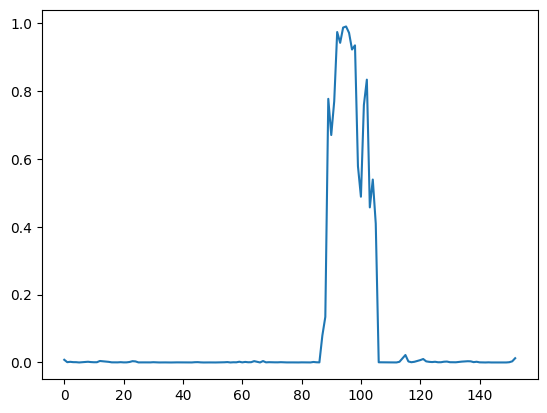

In [13]:
predictions = model.predict_proba(features)[:, 1]
plt.plot(predictions)

In [14]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(features)

In [172]:
np.argsort(np.argsort([5, 3, 4, 6]))

array([2, 0, 1, 3])

In [22]:
topNfeatures = 10
feature_columns = features.columns

args_max = pd.DataFrame(shap_values, columns=feature_columns).abs().T.apply(lambda x: len(feature_columns)-1-np.argsort(np.argsort(x)), axis=0).reset_index(drop=True)
top_features = args_max.iloc[:topNfeatures].T
top_features = top_features.apply(lambda x: feature_columns[x]).rename(columns={col: f'important_feature{col}' for col in top_features.columns}).set_index(features.index)

top_features_values = top_features.apply(
    lambda row: pd.Series(
        features.loc[row.name][[row[col] for col in top_features.columns]].values, 
        index=top_features.columns
    ), axis=1
)
top_features_w_val = top_features + '= '+ top_features_values.round(3).astype('string')

In [27]:
top_features_w_val

,important_feature0,important_feature1,important_feature2,important_feature3,important_feature4,important_feature5,important_feature6,important_feature7,important_feature8,important_feature9
game_play_frame_id,,,,,,,,,,
2022110600_56_1,frameType= 0.0,pca_feather_embedding_35= -0.016,pca_feather_embedding_0= 0.02,pca_feather_embedding_28= -0.085,fx__general= -161.877,pca_feather_embedding_9= -0.406,pca_feather_embedding_20= 0.051,distance_between_teams_std= 6.597,dis__general= 1.82,px__general= 69.485
2022110600_56_2,frameType= 0.0,pca_feather_embedding_34= 0.057,pca_feather_embedding_9= -0.294,pca_feather_embedding_28= -0.064,pca_feather_embedding_6= 0.049,pca_feather_embedding_10= -0.277,pca_feather_embedding_29= -0.038,pca_feather_embedding_0= 0.082,p__general= 3575.08,work__general= 367.156
2022110600_56_3,frameType= 0.0,pca_feather_embedding_35= -0.014,pca_feather_embedding_17= 0.045,pca_feather_embedding_27= 0.078,pca_feather_embedding_14= -0.098,pca_feather_embedding_10= -0.266,pca_feather_embedding_25= -0.119,pca_feather_embedding_20= 0.054,min_distance_to_football_defensive= 9.141,fy__general= -1154.48
2022110600_56_4,frameType= 0.0,pca_feather_embedding_34= -0.064,most_influence_possesion= 6.745,pca_feather_embedding_15= 0.07,pca_feather_embedding_31= -0.071,pca_feather_embedding_13= -0.288,pca_feather_embedding_22= -0.095,most_influence_encoded_position_possesion= 16.0,min_distance_to_football_defensive= 0.054,work__general= 369.395
2022110600_56_5,frameType= 0.0,pca_feather_embedding_35= -0.022,most_influence_encoded_position_defensive= 4.0,pca_feather_embedding_17= 0.088,pca_feather_embedding_29= -0.004,pca_feather_embedding_9= 0.1,pca_feather_embedding_15= 0.178,football_distance_defensive_team= 20.394,min_distance_to_football_possesion= 0.31,px__general= -121.467
...,...,...,...,...,...,...,...,...,...,...
2022110600_56_149,work__difference= -154.331,pca_feather_embedding_34= 0.007,pca_feather_embedding_20= 0.235,pca_feather_embedding_30= 0.204,x__difference= 1.541,distance_between_teams_max= 28.2,pca_feather_embedding_28= 0.26,pca_feather_embedding_0= -0.854,football_distance_general= 13.56,most_influence_encoded_position_defensive= 4.0
2022110600_56_150,fy__difference= 1034.703,pca_feather_embedding_35= -0.138,pca_feather_embedding_11= 0.269,pca_feather_embedding_28= 0.202,pca_feather_embedding_29= 0.051,pca_feather_embedding_18= 0.29,pca_feather_embedding_30= -0.021,current_position_influence__difference= 39.228,p__difference= 929.02,football_distance_possesion_team= 24.505
2022110600_56_151,ke__difference= 2981.841,pca_feather_embedding_35= 0.053,pca_feather_embedding_13= 0.642,pca_feather_embedding_22= 0.065,pca_feather_embedding_27= 0.057,pca_feather_embedding_23= -0.194,pca_feather_embedding_28= 0.15,current_position_influence__difference= 146.379,dis__general= 8.7,football_p= 3.841


<Axes: xlabel='game_play_frame_id'>

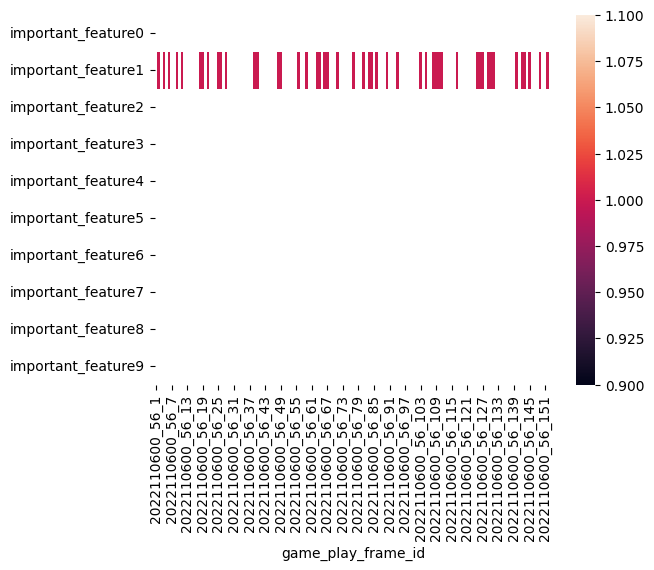

In [35]:
individual_feature = 'pca_feather_embedding_34'
sns.heatmap(top_features[top_features==individual_feature].replace({individual_feature:1}).T)

<Axes: xlabel='game_play_frame_id'>

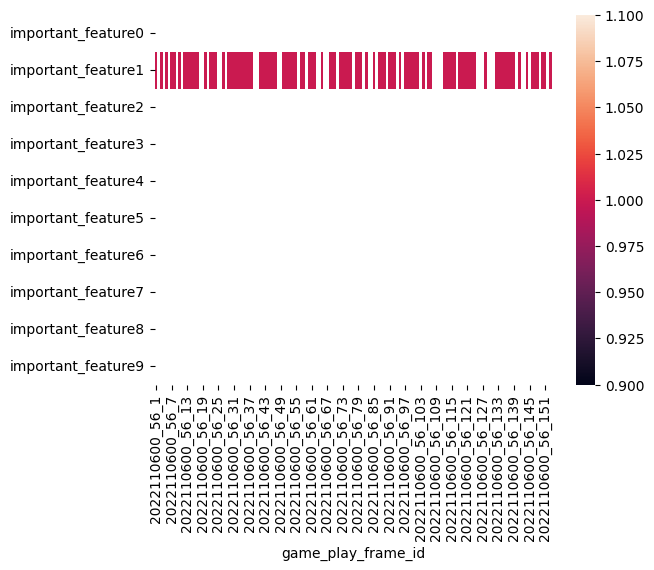

In [36]:
individual_feature = 'pca_feather_embedding_35'
sns.heatmap(top_features[top_features==individual_feature].replace({individual_feature:1}).T)

In [37]:
pd.set_option('display.max_rows', 153)

top_features

,important_feature0,important_feature1,important_feature2,important_feature3,important_feature4,important_feature5,important_feature6,important_feature7,important_feature8,important_feature9
game_play_frame_id,,,,,,,,,,
2022110600_56_1,frameType,pca_feather_embedding_35,pca_feather_embedding_0,pca_feather_embedding_28,fx__general,pca_feather_embedding_9,pca_feather_embedding_20,distance_between_teams_std,dis__general,px__general
2022110600_56_2,frameType,pca_feather_embedding_34,pca_feather_embedding_9,pca_feather_embedding_28,pca_feather_embedding_6,pca_feather_embedding_10,pca_feather_embedding_29,pca_feather_embedding_0,p__general,work__general
2022110600_56_3,frameType,pca_feather_embedding_35,pca_feather_embedding_17,pca_feather_embedding_27,pca_feather_embedding_14,pca_feather_embedding_10,pca_feather_embedding_25,pca_feather_embedding_20,min_distance_to_football_defensive,fy__general
2022110600_56_4,frameType,pca_feather_embedding_34,most_influence_possesion,pca_feather_embedding_15,pca_feather_embedding_31,pca_feather_embedding_13,pca_feather_embedding_22,most_influence_encoded_position_possesion,min_distance_to_football_defensive,work__general
2022110600_56_5,frameType,pca_feather_embedding_35,most_influence_encoded_position_defensive,pca_feather_embedding_17,pca_feather_embedding_29,pca_feather_embedding_9,pca_feather_embedding_15,football_distance_defensive_team,min_distance_to_football_possesion,px__general
2022110600_56_6,frameType,pca_feather_embedding_34,distance_between_teams_max,pca_feather_embedding_21,pca_feather_embedding_8,pca_feather_embedding_17,work__general,football_y,football_a,px__general
2022110600_56_7,frameType,pca_feather_embedding_35,pca_feather_embedding_29,pca_feather_embedding_20,pca_feather_embedding_2,pca_feather_embedding_12,pca_feather_embedding_27,most_influence_defensive,football_x,min_encoded_position_defensive
2022110600_56_8,frameType,pca_feather_embedding_35,pca_feather_embedding_26,pca_feather_embedding_22,pca_feather_embedding_11,pca_feather_embedding_15,pca_feather_embedding_23,most_influence_encoded_position_defensive,football_s,min_encoded_position_possesion
2022110600_56_9,frameType,pca_feather_embedding_34,pca_feather_embedding_18,pca_feather_embedding_27,pca_feather_embedding_4,pca_feather_embedding_7,pca_feather_embedding_13,pca_feather_embedding_6,min_distance_to_football_possesion,football_x


<Axes: xlabel='game_play_frame_id'>

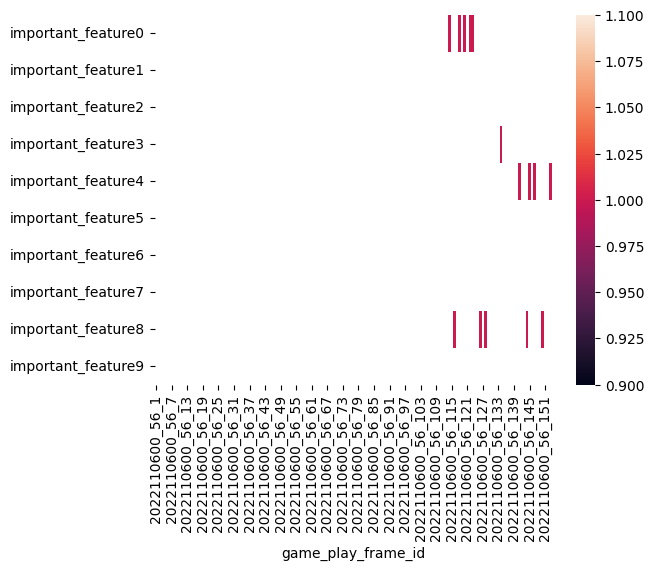

In [42]:
individual_feature = 'p__difference'
sns.heatmap(top_features[top_features==individual_feature].replace({individual_feature:1}).T)